1. Tahap awal dalam proses data mining adalah melakukan **persiapan data**. Pada tahap ini dilakukan import beberapa library yang diperlukan untuk proses analisis data, preprocessing, visualisasi, pembuatan model, dan evaluasi model. Library yang digunakan antara lain pandas untuk membaca dan mengelola data, numpy untuk operasi numerik, matplotlib.pyplot dan seaborn untuk visualisasi data, serta sklearn yang digunakan dalam proses machine learning seperti pembagian data, feature scaling, pembuatan model klasifikasi, dan evaluasi model. Setelah seluruh library berhasil diimport, langkah berikutnya adalah mengunggah dataset ke Google Colab agar data dapat dibaca dan digunakan dalam proses analisis.

In [31]:
import pandas as pd
import numpy as np

In [32]:
# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# preprocessing & model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [6]:
# model klasifikasi
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [7]:
# evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2. Kemudian, **dataset dibaca** menggunakan fungsi pd.read_csv(). Dataset yang digunakan terdiri dari data_training.csv dan data_testing.csv. Dataset training digunakan dalam proses pelatihan model karena telah memiliki variabel target berupa quality, sedangkan dataset testing digunakan untuk melakukan prediksi kualitas anggur.

In [12]:
train = pd.read_csv('/content/data_training.csv')
train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


In [9]:
data_testing= pd.read_csv('/content/data_testing.csv')
data_testing

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.610,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.580,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.600,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516
...,...,...,...,...,...,...,...,...,...,...,...,...
281,10.0,0.410,0.45,6.2,0.071,6.0,14.0,0.99702,3.21,0.49,11.800000,1147
282,10.6,0.830,0.37,2.6,0.086,26.0,70.0,0.99810,3.16,0.52,9.900000,296
283,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.100000,170
284,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,1439


In [13]:
data_training = train.drop_duplicates()

3. Setelah dataset berhasil diimport, dilakukan **pemeriksaan awal** terhadap data untuk memahami karakteristik dataset sebelum proses pemodelan dilakukan. Pemeriksaan awal dilakukan dengan melihat ukuran dataset menggunakan .shape untuk mengetahui jumlah baris dan kolom pada dataset training maupun testing. Selanjutnya dilakukan pengecekan tipe data dan informasi umum dataset menggunakan .info() guna mengetahui tipe data setiap variabel serta memastikan tidak terdapat permasalahan pada struktur data yang digunakan.

In [14]:
print ("Ukuran data training", data_training.shape)
print ("Ukuran data testing", data_testing.shape)

Ukuran data training (857, 13)
Ukuran data testing (286, 12)


In [15]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None


Dari hasil tersebut kita dapat mengetahui jumlah data, nama variabel, tipe data masing-masing kolom, serta apakah terdapat nilai kosong (missing value).

In [16]:
print(train.describe())
print(train.isnull().sum())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count     857.000000        857.000000   857.000000      857.000000   
mean        8.261960          0.529393     0.267351        2.506184   
std         1.701992          0.179162     0.195144        1.293512   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.395000     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.600000          1.580000     1.000000       15.500000   

        chlorides  free sulfur dioxide  total sulfur dioxide     density  \
count  857.000000           857.000000            857.000000  857.000000   
mean     0.086830            15.782964             45.978413    0.996692   
std      0.048721            10.300402             31.692113    0.001901   
min      0.012000             1.000000              6.00

Fungsi .isnull().sum() digunakan untuk menghitung jumlah missing value pada setiap kolom. Dari hasil yang telah dilakukan, dataset **tidak memiliki missing value** sehingga tidak diperlukan penghapusan data kosong.

In [17]:
print("Jumlah data duplikat:", train.duplicated().sum())

Jumlah data duplikat: 0


Pengecekan data duplikat dilakukan untuk mengetahui apakah terdapat data yang memiliki nilai atau isi yang sama persis dengan data lainnya dalam dataset. Keberadaan data duplikat dapat memengaruhi performa model karena dapat menyebabkan model mempelajari pola tertentu secara berlebihan sehingga hasil prediksi menjadi kurang optimal.

4. Selanjutnya tahap **eksplorasi data**.

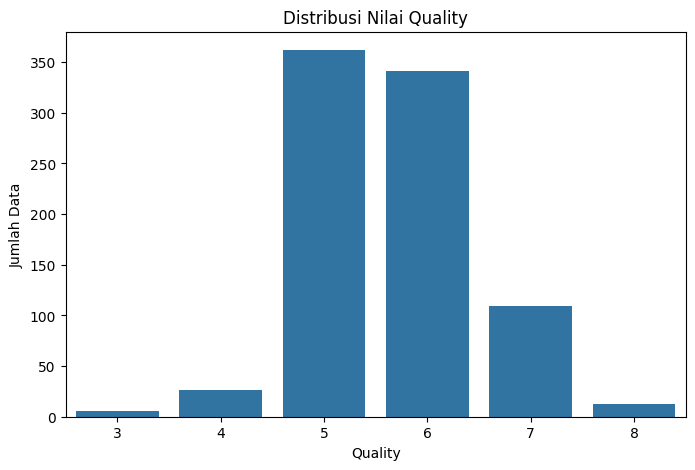

In [18]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=data_training)
plt.title('Distribusi Nilai Quality')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')
plt.show()

a. Visualisasi dengan menggunakan countplot tujuannya untuk menunjukkan jumlah data pada masing-masing kategori kualitas anggur.

In [19]:
data_training['quality'].value_counts().sort_index()

,count
quality,
3,6
4,26
5,362
6,341
7,109
8,13


Berdasarkan hasil tersebut, dapat terlihat bahwa jumlah data pada masing-masing kelas belum terdistribusi secara seimbang. Kondisi ini perlu diperhatikan karena ketidakseimbangan kelas dapat memengaruhi kinerja model klasifikasi dalam melakukan prediksi.

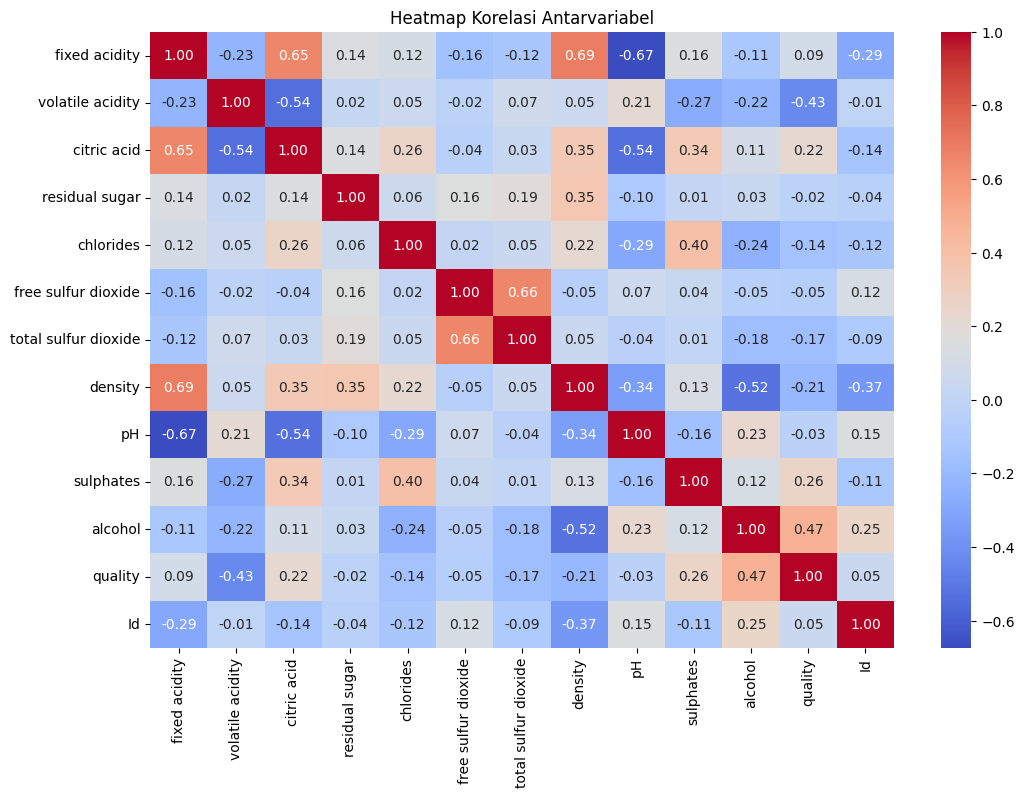

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(data_training.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antarvariabel')
plt.show()

b. Analisis korelasi dengan menggunakan heatmap tujuannya untuk mengetahui hubungan atau tingkat korelasi antarfitur dalam dataset. Nilai korelasi berada pada rentang −1 hingga 1, di mana nilai −1 menunjukkan hubungan negatif yang sangat kuat, nilai 0 menunjukkan tidak adanya hubungan, dan nilai 1 menunjukkan hubungan positif yang sangat kuat.

4. Pada tahap ini dilakukan **pemisahan fitur dan target**.  
- Variabel target: quality, yaitu kualitas dari anggur yang akan diprediksi.
- Variabel fitur: seluruh kolom selain quality dan Id.

In [21]:
x = train.drop(['quality','Id'], axis=1)
y = train['quality']

x_test_final=data_testing.drop(['Id'],axis=1)

In [22]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x, y,
test_size=0.2,
random_state=42,
stratify=y
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
test_scaled = scaler.transform(x_test_final)

5. **Model pertama** yang digunakan adalah **K-Nearest Neighbor (KNN)**.

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train_scaled, y_train)

y_pred_knn = knn.predict(x_val_scaled)

print("Akurasi KNN:", accuracy_score(y_val, y_pred_knn))
print(classification_report(y_val, y_pred_knn))

Akurasi KNN: 0.48255813953488375
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.54      0.59      0.56        73
           6       0.46      0.43      0.44        68
           7       0.48      0.50      0.49        22
           8       0.00      0.00      0.00         3

    accuracy                           0.48       172
   macro avg       0.25      0.25      0.25       172
weighted avg       0.47      0.48      0.48       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
cm_knn = confusion_matrix(y_val, y_pred_knn)

print("Confusion Matrix KNN:")
print(cm_knn)

Confusion Matrix KNN:
[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  5 43 24  1  0]
 [ 0  1 29 29  9  0]
 [ 0  0  3  8 11  0]
 [ 0  0  0  1  2  0]]


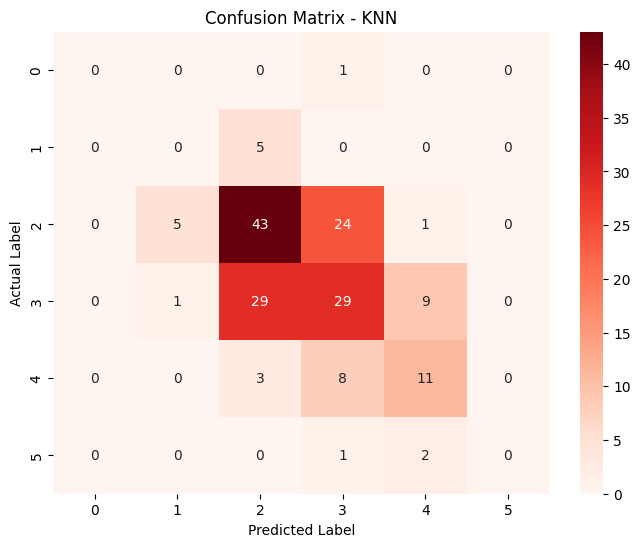

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - KNN')

plt.show()

Pada confusion matrix, baris menunjukkan kelas aktual sedangkan kolom menunjukkan kelas hasil prediksi model. Nilai pada diagonal confusion matrix menunjukkan jumlah prediksi yang benar, sehingga semakin besar nilai diagonal maka performa model semakin baik. Sebaliknya, nilai di luar diagonal menunjukkan adanya kesalahan klasifikasi, misalnya data dengan kualitas tertentu diprediksi ke kelas kualitas lain yang berdekatan. Berdasarkan hasil confusion matrix pada model K-Nearest Neighbor (KNN) yang telah dilakukan, masih terdapat beberapa kesalahan prediksi antar kelas quality yang nilainya berdekatan. Hal ini disebabkan karena model KNN melakukan klasifikasi berdasarkan kedekatan jarak data terhadap sejumlah tetangga terdekat yang digunakan dalam proses prediksi.

6. **Model kedua** yang digunakan adalah **Random Forest**.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(x_train, y_train)
y_pred_rf=rf.predict(x_val)
print ("Akurasi Random Forest", accuracy_score(y_val, y_pred_rf))
print (classification_report(y_val, y_pred_rf))

Akurasi Random Forest 0.6569767441860465
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.84      0.76        73
           6       0.62      0.66      0.64        68
           7       0.50      0.27      0.35        22
           8       1.00      0.33      0.50         3

    accuracy                           0.66       172
   macro avg       0.47      0.35      0.38       172
weighted avg       0.63      0.66      0.63       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_rf)

print("Confusion Matrix Random Forest:")
print(cm)

Confusion Matrix Random Forest:
[[ 0  0  1  0  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 61 11  1  0]
 [ 0  0 20 45  3  0]
 [ 0  0  0 16  6  0]
 [ 0  0  0  0  2  1]]


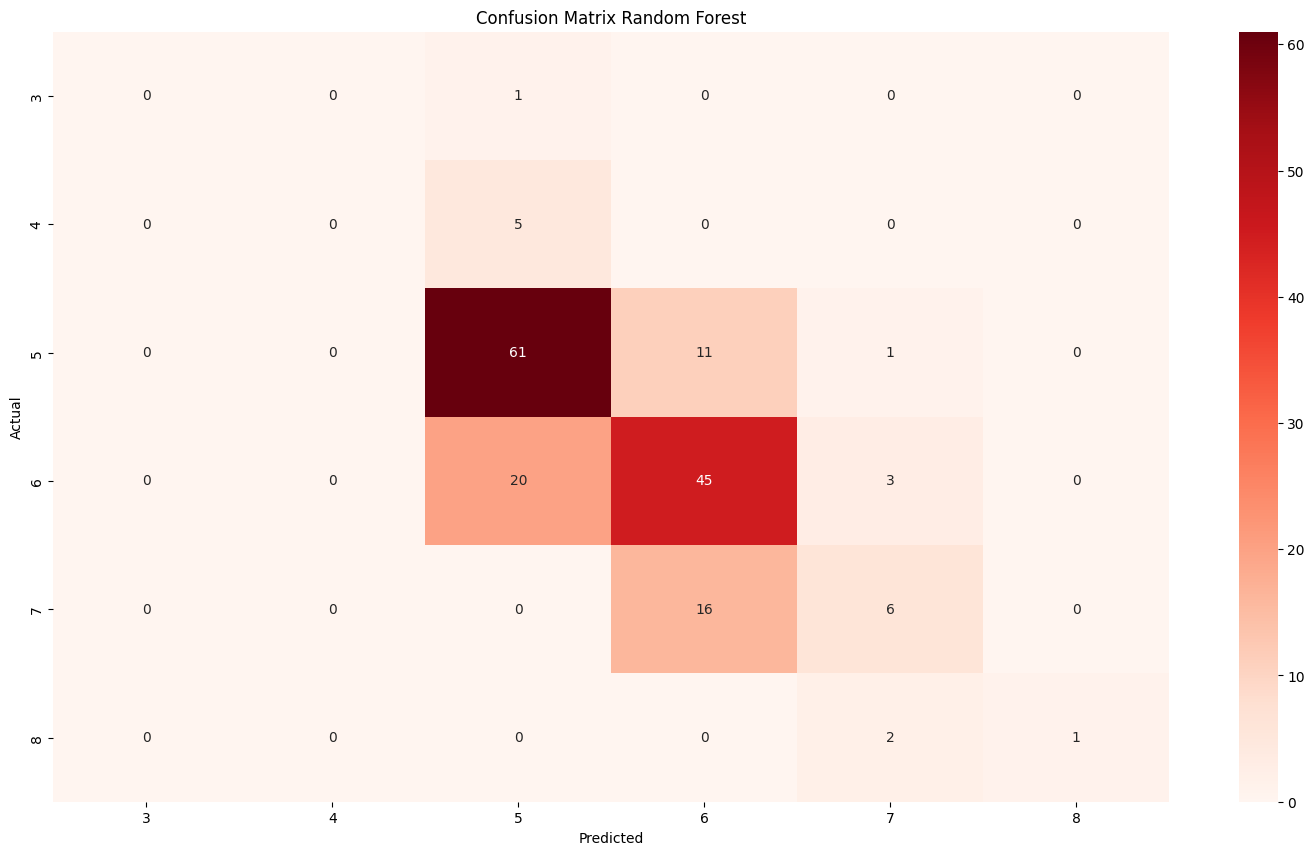

In [29]:
labels = sorted(y.unique())

plt.figure(figsize=(18,10))
sns.heatmap(cm, annot=True, cmap='Reds', fmt='d',
           xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Random Forest')
plt.show()

Pada confusion matrix model Random Forest, baris menunjukkan kelas aktual sedangkan kolom menunjukkan kelas hasil prediksi model. Nilai pada diagonal confusion matrix menunjukkan jumlah prediksi yang benar, sehingga semakin besar nilai diagonal maka performa model semakin baik. Berdasarkan hasil confusion matrix pada model Random Forest yang telah dilakukan mampu menghasilkan prediksi yang lebih baik dibandingkan model sebelumnya karena jumlah prediksi benar pada diagonal lebih dominan dan kesalahan klasifikasi lebih sedikit. Meskipun demikian, masih terdapat beberapa kesalahan prediksi pada kelas kualitas yang nilainya berdekatan. Hal ini dapat terjadi karena karakteristik data antar kelas memiliki pola yang hampir serupa sehingga model masih mengalami kesulitan dalam membedakan beberapa kelas tertentu.

7. **Model ketiga** yang digunakan adalah **Decision Tree**.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_val)

print("Akurasi Decision Tree:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

Akurasi Decision Tree: 0.6046511627906976
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.74      0.70        73
           6       0.61      0.56      0.58        68
           7       0.58      0.50      0.54        22
           8       0.50      0.33      0.40         3

    accuracy                           0.60       172
   macro avg       0.39      0.36      0.37       172
weighted avg       0.60      0.60      0.60       172



In [ ]:
cm_dt = confusion_matrix(y_val, y_pred_dt)

print("Confusion Matrix Decision Tree:")
print(cm_dt)

Confusion Matrix Decision Tree:
[[ 0  0  1  0  0  0]
 [ 0  0  2  3  0  0]
 [ 2  2 54 13  2  0]
 [ 1  1 23 38  4  1]
 [ 0  1  2  8 11  0]
 [ 0  0  0  0  2  1]]


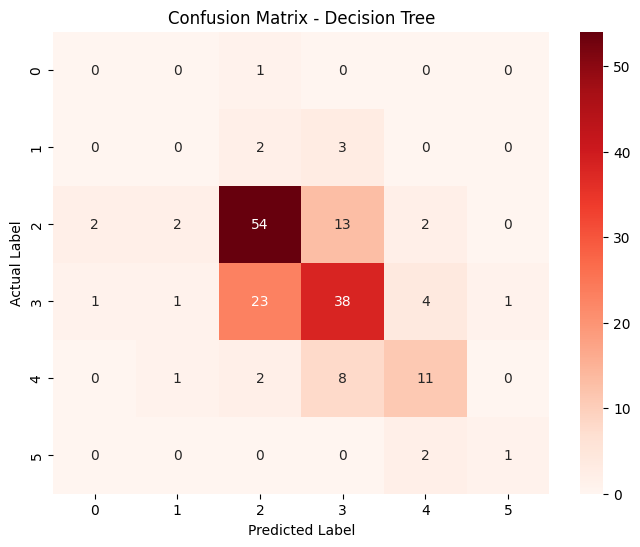

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Reds')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Decision Tree')

plt.show()

Berdasarkan hasil confusion matrix pada model Decision Tree yang telah dilakukan, terlihat bahwa model telah mampu melakukan klasifikasi pada beberapa kelas quality dengan cukup baik. Hal ini ditunjukkan oleh adanya nilai pada bagian diagonal confusion matrix yang menunjukkan jumlah prediksi benar. Namun, dibandingkan dengan model Random Forest, masih terdapat lebih banyak kesalahan klasifikasi pada beberapa kelas kualitas. Kesalahan prediksi umumnya terjadi pada kelas quality yang memiliki nilai berdekatan. Hal ini menunjukkan bahwa model Decision Tree masih mengalami kesulitan dalam membedakan pola data antar kelas tertentu. Selain itu, Decision Tree cenderung lebih mudah mengalami overfitting karena model membentuk aturan keputusan berdasarkan data pelatihan secara detail. Meskipun demikian, model ini tetap mampu memberikan performa klasifikasi yang cukup baik dalam memprediksi kualitas anggur berdasarkan fitur-fitur kimiawi yang tersedia.

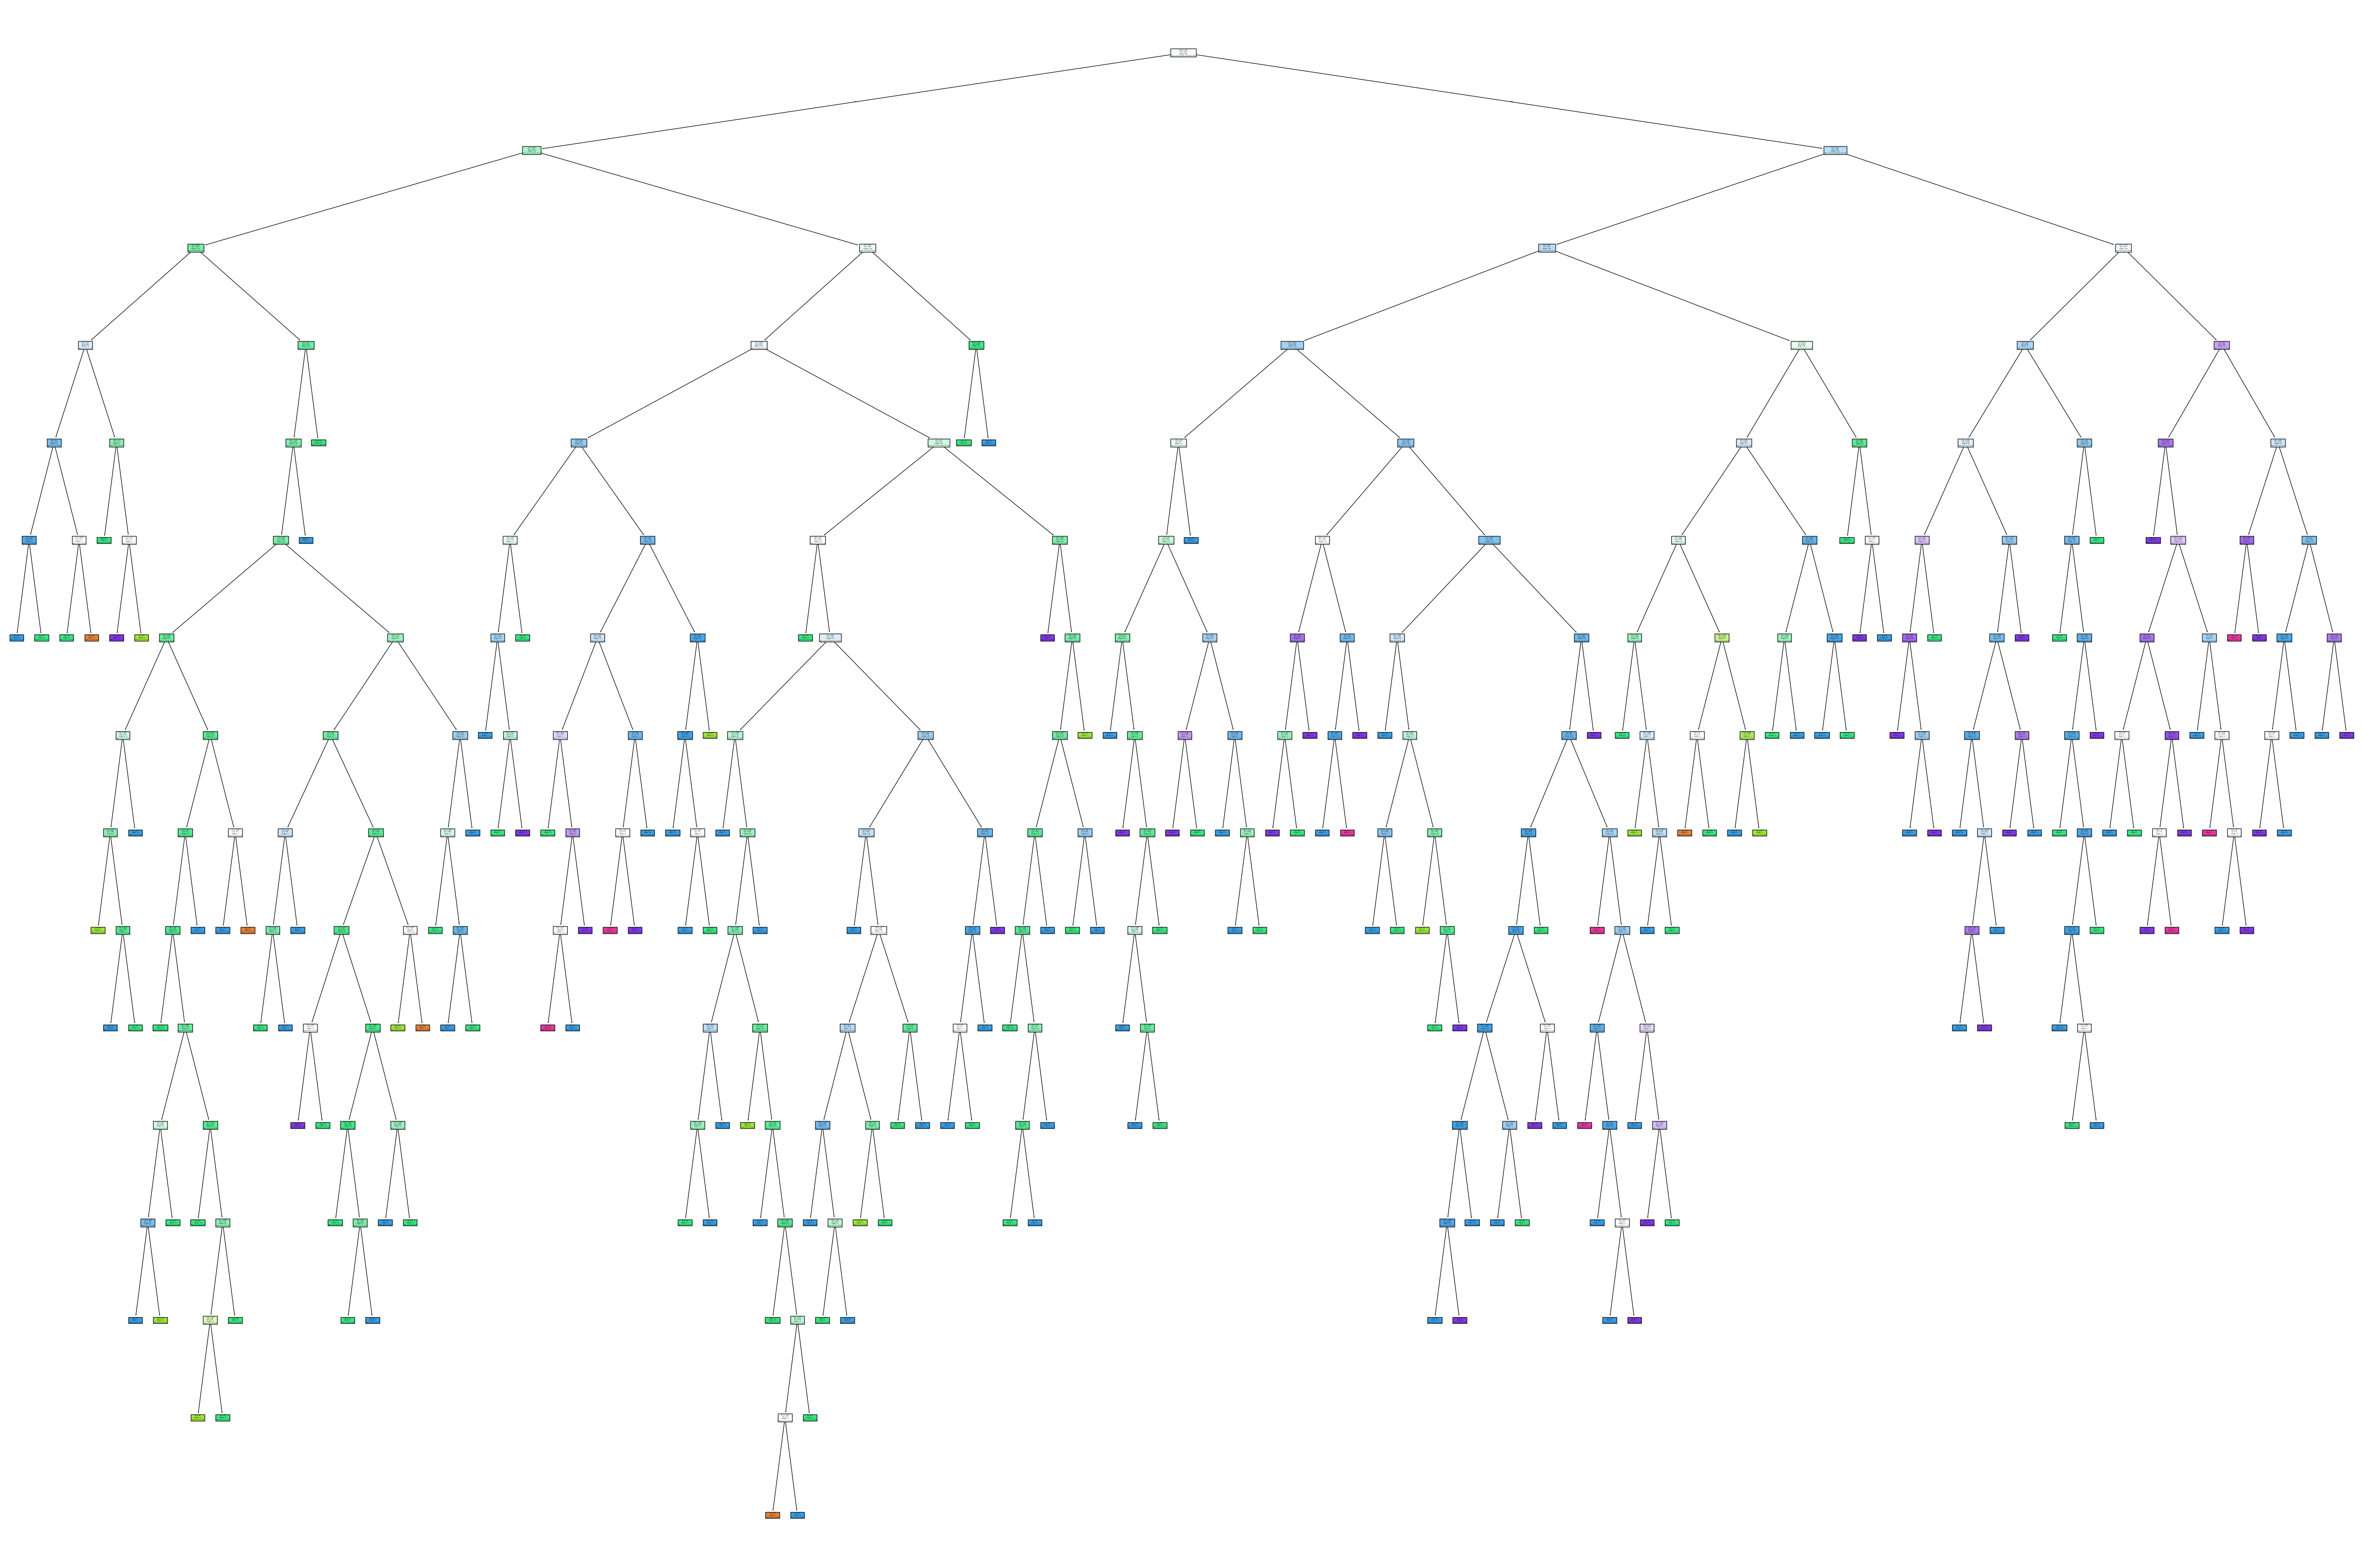

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize = (75,50))
plot_tree(classifier.fit(x_train, y_train), filled=True)
plt.show()

In [ ]:
#Membandingkan Akurasi Model
akurasi_knn = accuracy_score(y_val, y_pred_knn)
akurasi_rf = accuracy_score(y_val, y_pred_rf)
akurasi_dt = accuracy_score(y_val, y_pred_dt)

hasil_model = pd.DataFrame({
    'Model': ['KNN', 'Random Forest', 'Decision Tree'],
    'Akurasi': [akurasi_knn, akurasi_rf, akurasi_dt]
})

hasil_model

,Model,Akurasi
0,KNN,0.482558
1,Random Forest,0.645349
2,Decision Tree,0.604651


Dari ketiga model klasifikasi di atas, diperoleh model terbaik adalah Random Forest.

8. Karena **Random Forest dipilih sebagai model terbaik**, maka dilakukan **pelatihan ulang** menggunakan seluruh data training yang tersedia sebelum model digunakan untuk memprediksi data testing. Langkah ini bertujuan agar model dapat mempelajari pola data secara lebih optimal sehingga hasil prediksi yang dihasilkan menjadi lebih baik.

In [37]:
model_terbaik = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# Fit the model using scaled training data (NumPy array)
model_terbaik.fit(scaler.transform(x), y)

RandomForestClassifier(class_weight='balanced', random_state=42)

9. Model terbaik (Random Forest) kemudian digunakan untuk memprediksi kualitas anggur pada data testing.

In [ ]:
hasil_prediksi = pd.DataFrame({
    'Id': data_testing['Id'],
    'quality': prediksi_quality
})

hasil_prediksi.head()

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5


10. Pengecekan missing value sebelum menyimpan file.

In [ ]:
hasil_prediksi.isnull().sum()

,0
Id,0
quality,0


11. Mengunduh file.

In [38]:
from google.colab import files
from sklearn.ensemble import RandomForestClassifier

# Check if model_terbaik is defined, if not, re-train it
if 'model_terbaik' not in globals():
    model_terbaik = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    )
    # Re-train model_terbaik using scaled data (NumPy array) if not already defined
    model_terbaik.fit(scaler.transform(x), y)

prediksi_quality = model_terbaik.predict(test_scaled)

hasil_prediksi = pd.DataFrame({
    'Id': data_testing['Id'],
    'quality': prediksi_quality
})

hasil_prediksi.to_csv('hasil_prediksi_quality.csv',index=False)
files.download('hasil_prediksi_quality.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

12. Hasil prediksi yang diperoleh dalam pengolahan data.

In [ ]:
hasil["quality"].value_counts().sort_index()

,count
quality,
5,134
6,123
7,28
8,1


**KESIMPULAN:**

Berdasarkan proses analisis dan pemodelan data yang telah dilakukan pada dataset kualitas anggur, dapat disimpulkan bahwa tahapan data mining berhasil diterapkan mulai dari persiapan data, eksplorasi data, preprocessing, hingga pembuatan model klasifikasi. Dataset yang digunakan tidak memiliki missing value maupun data duplikat sehingga data dinilai cukup baik untuk digunakan dalam proses pemodelan.

Hasil eksplorasi data menunjukkan bahwa distribusi kelas kualitas anggur belum seimbang, di mana sebagian besar data berada pada kelas quality 5 dan 6. Selain itu, analisis korelasi menunjukkan adanya hubungan antarfitur kimiawi yang dapat memengaruhi kualitas anggur.

Pada penelitian ini digunakan tiga model klasifikasi, yaitu KNN, Decision Tree, dan Random Forest. Berdasarkan hasil evaluasi model, diperoleh nilai akurasi sebagai berikut:
- KNN : 48,26%
- Decision Tree : 60,47%
- Random Forest : 64,53%

Dari hasil tersebut dapat diketahui bahwa model Random Forest memiliki performa terbaik dibandingkan model lainnya karena menghasilkan nilai akurasi tertinggi serta confusion matrix yang menunjukkan jumlah prediksi benar lebih dominan. Hal ini menunjukkan bahwa Random Forest lebih mampu mengenali pola data dan melakukan klasifikasi kualitas anggur dengan lebih baik.

Dengan demikian, model Random Forest dipilih sebagai model terbaik dan digunakan untuk memprediksi kualitas anggur pada data testing. Secara keseluruhan, fitur-fitur kimiawi pada dataset mampu digunakan untuk memprediksi kualitas anggur menggunakan metode machine learning klasifikasi.